In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline 
plt.style.use("fivethirtyeight")

df=pd.read_csv("https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv",parse_dates=["Date"])
df["Total Cases"]=df[["Confirmed","Recovered","Deaths"]].sum(axis=1)

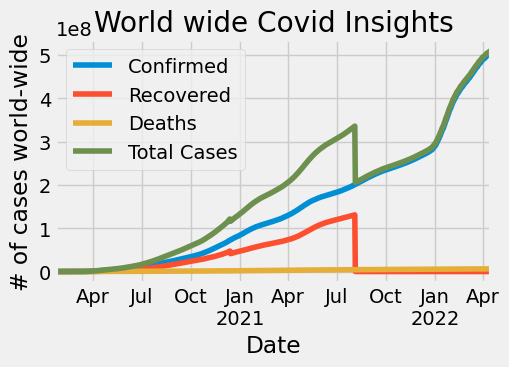

In [42]:
# world wide trend

worldwide_df=df.groupby(["Date"]).sum()
w=worldwide_df.plot(figsize=(5,3))
w.set_xlabel("Date")
w.set_ylabel("# of cases world-wide")
w.title.set_text("World wide Covid Insights")

plt.show()

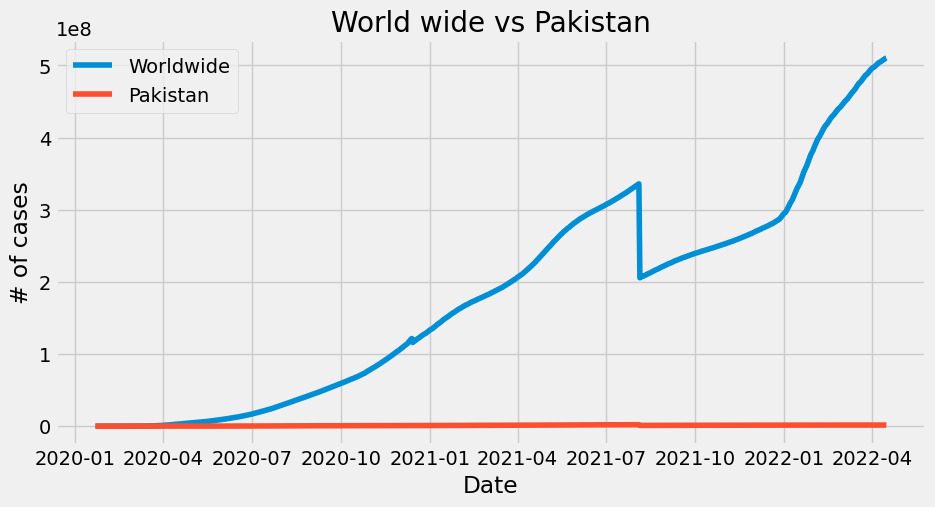

In [43]:
#now if we want to see the world wide trend wrt pakistan 
pk_df=df[df['Country']=='Pakistan'].groupby(['Date']).sum()
fig=plt.figure(figsize=(10,5))
ax=fig.add_subplot(111)
ax.plot(worldwide_df[['Total Cases']],label='Worldwide')
ax.plot(pk_df[['Total Cases']],label='Pakistan')
ax.set_xlabel('Date')
ax.set_ylabel('# of cases')
ax.set_title('World wide vs Pakistan')

plt.legend(loc='upper left')
plt.show()


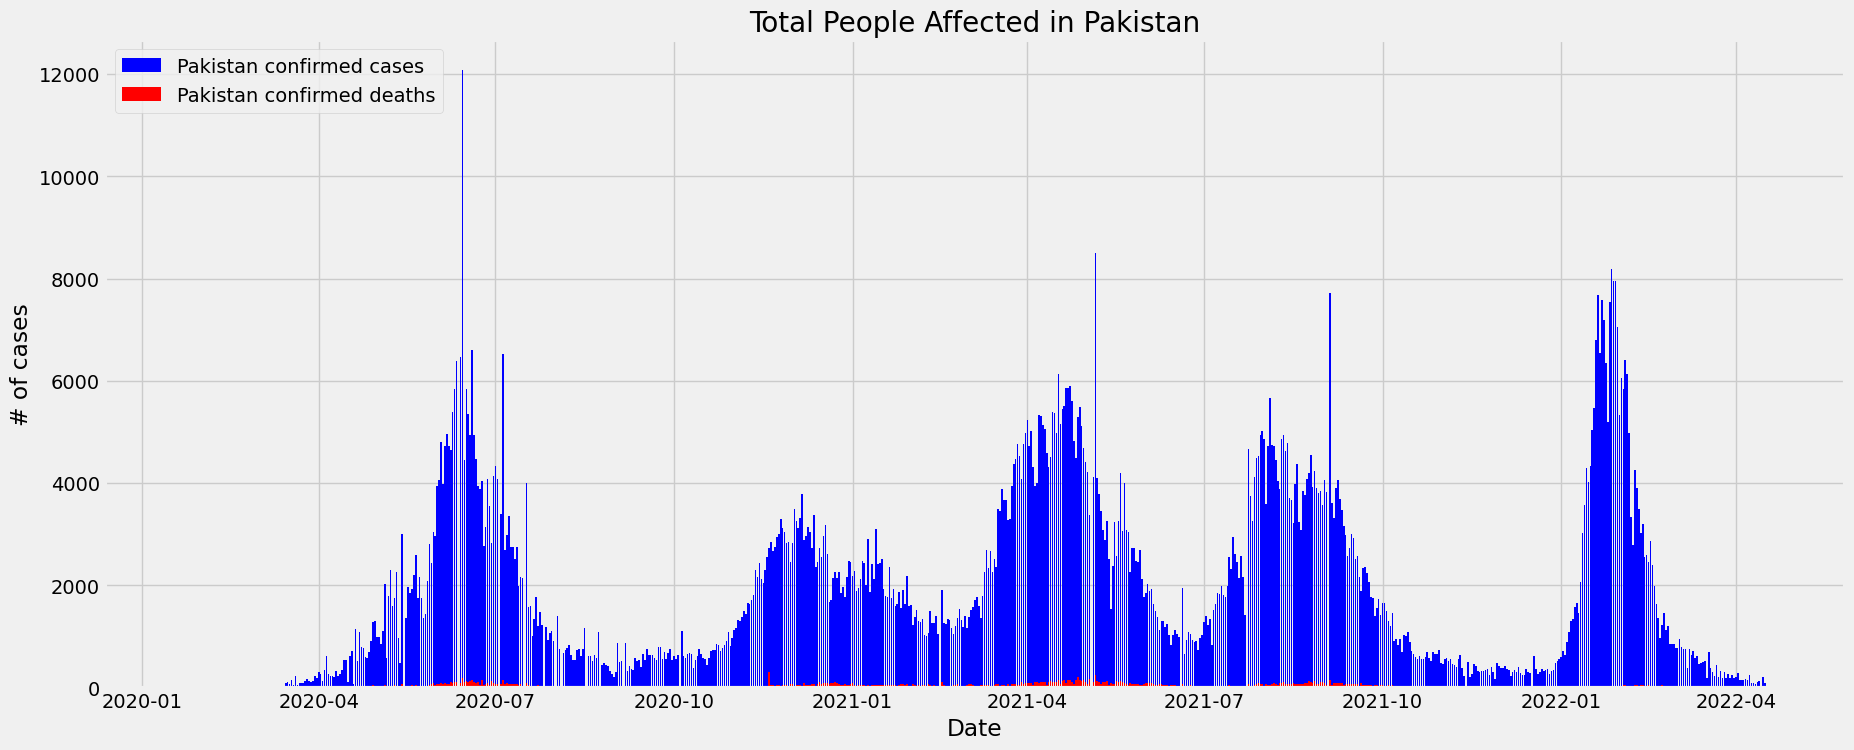

In [44]:
# no of cases and death in Pakistan so we've to made 2 cols confirmed deaths and confirmed cases
pk_df=pk_df.reset_index() #this line is necessary here ?
pk_df['Daily Confirmed']=pk_df['Confirmed'].sub(pk_df['Confirmed'].shift())
pk_df['Daily Deaths']=pk_df['Deaths'].sub(pk_df['Deaths'].shift())

fig=plt.figure(figsize=(20,8))
ax=fig.add_subplot(111)

ax.bar(pk_df['Date'], pk_df['Daily Confirmed'],color='b',label='Pakistan confirmed cases')
ax.bar(pk_df['Date'], pk_df['Daily Deaths'],color='r',label='Pakistan confirmed deaths')

ax.set_xlabel('Date')
ax.set_ylabel('# of cases')
ax.set_title('Total People Affected in Pakistan')

plt.legend(loc='upper left')
plt.show()

C:\Users\auran\AppData\Local\Temp\ipykernel_6468\1832418684.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  top_10.loc['Rest-of-World']=df_today.sort_values(['Confirmed'],ascending=False)[10:].sum(numeric_only=True)


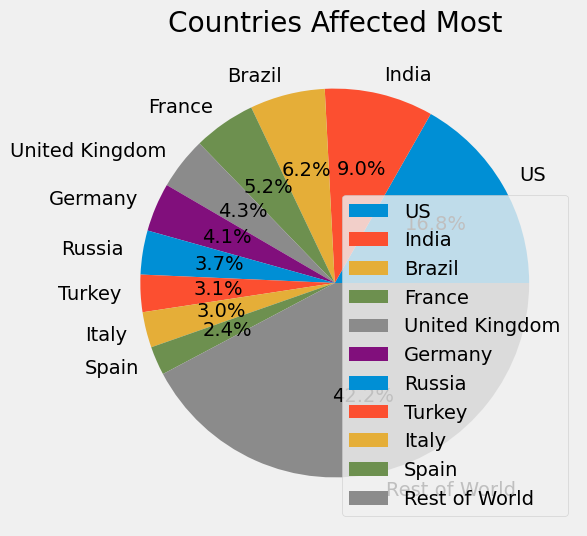

In [102]:

from datetime import date,timedelta

yesterday=date.today() - timedelta(days=900)
yesterday.strftime('%Y-%m-%d')


#checking the possible error
#print(yesterday)
#print(df['Date'].unique())


df_today=df[df['Date'].dt.date==yesterday]
top_10=df_today.sort_values(['Confirmed'],ascending=False)[:10]
top_10.loc['Rest-of-World']=df_today.sort_values(['Confirmed'],ascending=False)[10:].sum(numeric_only=True)
top_10.loc['Rest-of-World','Country']='Rest of World'

fig=plt.figure(figsize=(6,6))
ax=fig.add_subplot(111)

ax.pie(top_10['Confirmed'],labels=top_10['Country'],autopct='%1.1f%%')
ax.set_title('Countries Affected Most')

plt.legend(loc='lower right')
plt.show()
